In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/ekowannanindome/eda-v1/__results__.html
/kaggle/input/notebooks/ekowannanindome/eda-v1/__notebook__.ipynb
/kaggle/input/notebooks/ekowannanindome/eda-v1/__output__.json
/kaggle/input/notebooks/ekowannanindome/eda-v1/custom.css
/kaggle/input/notebooks/ekowannanindome/eda-v1/__results___files/__results___14_0.png
/kaggle/input/notebooks/ekowannanindome/eda-v1/__results___files/__results___22_0.png
/kaggle/input/notebooks/ekowannanindome/eda-v1/__results___files/__results___24_0.png
/kaggle/input/notebooks/ekowannanindome/eda-v1/__results___files/__results___16_0.png
/kaggle/input/notebooks/ekowannanindome/eda-v1/__results___files/__results___29_0.png
/kaggle/input/notebooks/ekowannanindome/eda-v1/__results___files/__results___11_1.png
/kaggle/input/notebooks/ekowannanindome/eda-v1/__results___files/__results___18_0.png
/kaggle/input/notebooks/ekowannanindome/eda-v1/__results___files/__results___26_0.png
/kaggle/input/datasets/ekowannanindome/stellar-dataset/sample

## 1. Imports & Config

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [3]:
CFG = dict(
    n_folds      = 5,
    seed         = 42,
    n_estimators = 1000,
    early_stop   = 50,
    # Redshift thresholds for the rule-based sanity baseline
    star_thresh  = 0.15,   # redshift < this  → STAR
    qso_thresh   = 1.00,   # redshift > this  → QSO
)

LGBM_PARAMS = dict(
    n_estimators    = CFG['n_estimators'],
    learning_rate   = 0.05,
    num_leaves      = 127,
    min_child_samples = 50,
    subsample       = 0.8,
    colsample_bytree = 0.8,
    class_weight    = 'balanced',
    n_jobs          = -1,
    random_state    = CFG['seed'],
    verbose         = -1,
)

## 2. Load Data

In [4]:
train = pd.read_csv('/kaggle/input/datasets/ekowannanindome/stellar-dataset/train.csv', index_col='id')
test  = pd.read_csv('/kaggle/input/datasets/ekowannanindome/stellar-dataset/test.csv',  index_col='id')

print(f'Train: {train.shape}  |  Test: {test.shape}')

Train: (577347, 11)  |  Test: (247435, 10)


## 3. Feature Engineering

In [5]:
def add_color_indices(df):
    df = df.copy()
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    df['u_r'] = df['u'] - df['r']
    df['g_i'] = df['g'] - df['i']
    df['g_z'] = df['g'] - df['z']
    return df

train = add_color_indices(train)
test  = add_color_indices(test)

COLOR_COLS = ['u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'g_i', 'g_z']
print('Color indices added:', COLOR_COLS)

Color indices added: ['u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'g_i', 'g_z']


## 4. Preprocessing

In [6]:
CAT_COLS = ['spectral_type', 'galaxy_population']
NUM_COLS = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
FEAT_COLS = NUM_COLS + COLOR_COLS + CAT_COLS
TARGET = 'class'

# Encode categoricals — fit on train, apply to both
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
train[CAT_COLS] = oe.fit_transform(train[CAT_COLS])
test[CAT_COLS]  = oe.transform(test[CAT_COLS])

# Encode target
le = LabelEncoder()
y = le.fit_transform(train[TARGET])
print('Class mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

X      = train[FEAT_COLS]
X_test = test[FEAT_COLS]
print(f'\nFeature matrix: {X.shape}')

Class mapping: {'GALAXY': np.int64(0), 'QSO': np.int64(1), 'STAR': np.int64(2)}

Feature matrix: (577347, 17)


## 5. Threshold Baseline (Redshift Rule)

In [7]:
def threshold_predict(redshift_series, star_thresh, qso_thresh):
    preds = pd.Series('GALAXY', index=redshift_series.index)
    preds[redshift_series < star_thresh] = 'STAR'
    preds[redshift_series > qso_thresh]  = 'QSO'
    return preds

rule_preds = threshold_predict(
    train['redshift'],
    CFG['star_thresh'],
    CFG['qso_thresh']
)

rule_score = balanced_accuracy_score(train[TARGET], rule_preds)
print(f'Threshold rule balanced accuracy: {rule_score:.5f}')
print(f'  (star_thresh={CFG["star_thresh"]}, qso_thresh={CFG["qso_thresh"]})')

Threshold rule balanced accuracy: 0.83187
  (star_thresh=0.15, qso_thresh=1.0)


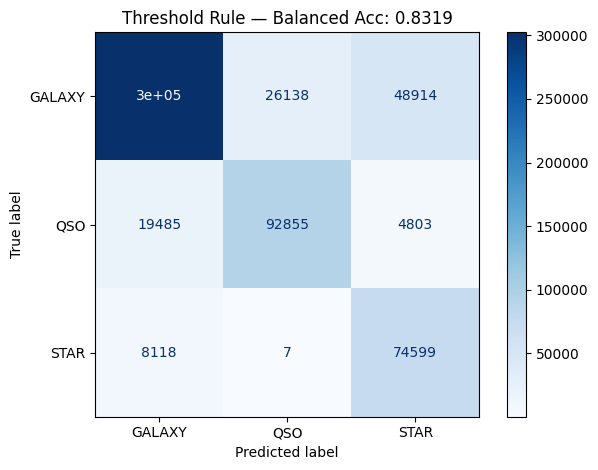

In [8]:
# Confusion matrix for the rule baseline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

classes_ordered = ['GALAXY', 'QSO', 'STAR']
cm = confusion_matrix(train[TARGET], rule_preds, labels=classes_ordered)
disp = ConfusionMatrixDisplay(cm, display_labels=classes_ordered)
disp.plot(cmap='Blues')
plt.title(f'Threshold Rule — Balanced Acc: {rule_score:.4f}')
plt.tight_layout()

## 6. LightGBM — Stratified 5-Fold CV

In [9]:
skf = StratifiedKFold(n_splits=CFG['n_folds'], shuffle=True, random_state=CFG['seed'])

oof_proba  = np.zeros((len(X), len(le.classes_)))
test_proba = np.zeros((len(X_test), len(le.classes_)))
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    model = lgb.LGBMClassifier(**LGBM_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(CFG['early_stop'], verbose=False),
            lgb.log_evaluation(200),
        ],
        categorical_feature=CAT_COLS,
    )

    val_proba = model.predict_proba(X_val)
    val_preds = le.inverse_transform(val_proba.argmax(axis=1))
    val_true  = le.inverse_transform(y_val)

    score = balanced_accuracy_score(val_true, val_preds)
    fold_scores.append(score)
    oof_proba[val_idx] = val_proba
    test_proba += model.predict_proba(X_test) / CFG['n_folds']

    print(f'  Fold {fold+1}/{CFG["n_folds"]} | best_iter={model.best_iteration_} | balanced_acc={score:.5f}')

print(f'\nCV mean:  {np.mean(fold_scores):.5f}')
print(f'CV std:   {np.std(fold_scores):.5f}')

[200]	valid_0's multi_logloss: 0.105049
[400]	valid_0's multi_logloss: 0.0992136
[600]	valid_0's multi_logloss: 0.0974127
[800]	valid_0's multi_logloss: 0.0970496
  Fold 1/5 | best_iter=768 | balanced_acc=0.96438
[200]	valid_0's multi_logloss: 0.108003
[400]	valid_0's multi_logloss: 0.102674
[600]	valid_0's multi_logloss: 0.100825
  Fold 2/5 | best_iter=716 | balanced_acc=0.96449
[200]	valid_0's multi_logloss: 0.109496
[400]	valid_0's multi_logloss: 0.103997
[600]	valid_0's multi_logloss: 0.102274
[800]	valid_0's multi_logloss: 0.101893
  Fold 3/5 | best_iter=776 | balanced_acc=0.96364
[200]	valid_0's multi_logloss: 0.106449
[400]	valid_0's multi_logloss: 0.101266
[600]	valid_0's multi_logloss: 0.0996358
[800]	valid_0's multi_logloss: 0.0992542
  Fold 4/5 | best_iter=771 | balanced_acc=0.96395
[200]	valid_0's multi_logloss: 0.108242
[400]	valid_0's multi_logloss: 0.10288
[600]	valid_0's multi_logloss: 0.101088
[800]	valid_0's multi_logloss: 0.100504
  Fold 5/5 | best_iter=786 | balance

In [10]:
# OOF score (more reliable than mean of fold scores for imbalanced problems)
oof_preds_labels = le.inverse_transform(oof_proba.argmax(axis=1))
oof_true_labels  = le.inverse_transform(y)
oof_score = balanced_accuracy_score(oof_true_labels, oof_preds_labels)

print(f'OOF balanced accuracy: {oof_score:.5f}')
print(f'Threshold rule:        {rule_score:.5f}')
print(f'Gain over rule:        +{oof_score - rule_score:.5f}')

OOF balanced accuracy: 0.96418
Threshold rule:        0.83187
Gain over rule:        +0.13231


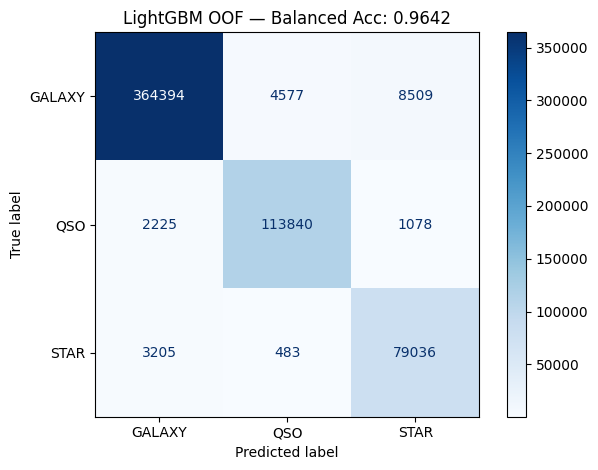

In [11]:
# OOF confusion matrix
cm_oof = confusion_matrix(oof_true_labels, oof_preds_labels, labels=classes_ordered)
disp_oof = ConfusionMatrixDisplay(cm_oof, display_labels=classes_ordered)
disp_oof.plot(cmap='Blues')
plt.title(f'LightGBM OOF — Balanced Acc: {oof_score:.4f}')
plt.tight_layout()

## 7. Feature Importance

          feature  importance
            alpha       32355
            delta       31805
         redshift       26624
              i_z       20265
              r_i       20007
              u_g       19596
              g_z       18446
              u_r       17262
              g_r       16893
                u       16625
              g_i       16298
                z       16010
                r       15711
                g       14674
                i       14333
    spectral_type         115
galaxy_population          89


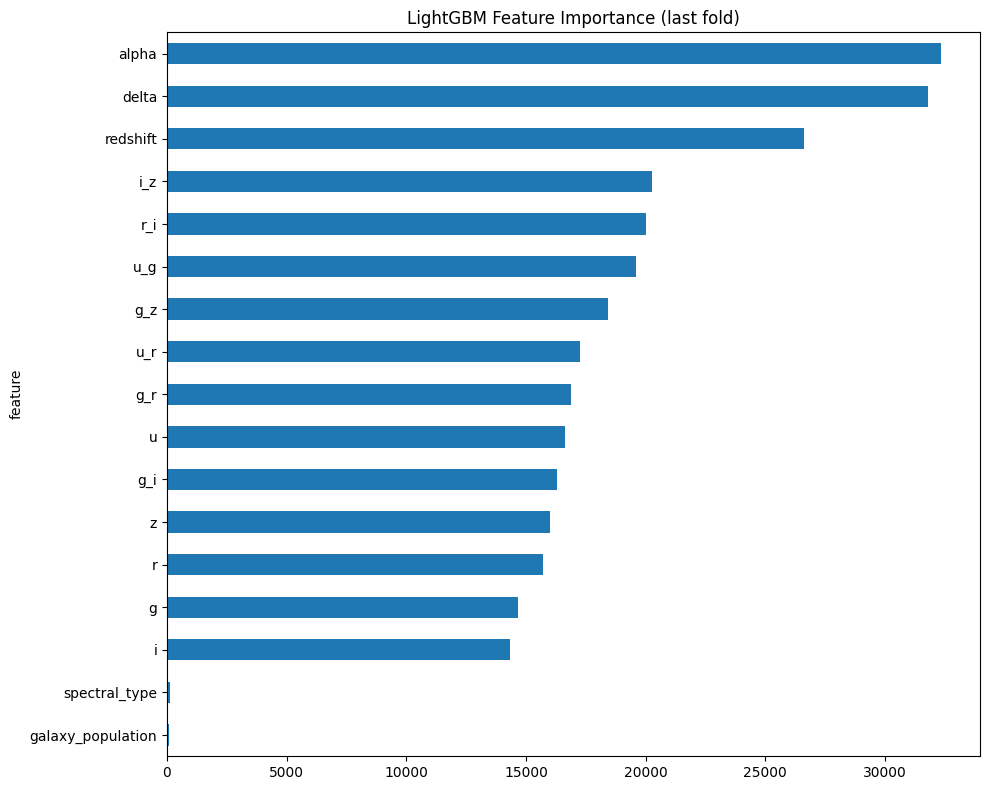

In [12]:
# Use the last fold's model — importance is stable across folds for this dataset size
importance_df = pd.DataFrame({
    'feature':   X.columns,
    'importance': model.feature_importances_,
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
importance_df.plot.barh(x='feature', y='importance', ax=ax, legend=False)
ax.set_title('LightGBM Feature Importance (last fold)')
ax.invert_yaxis()
plt.tight_layout()

print(importance_df.to_string(index=False))

## 8. Per-Class Performance

In [13]:
from sklearn.metrics import classification_report

print(classification_report(oof_true_labels, oof_preds_labels, target_names=classes_ordered))

              precision    recall  f1-score   support

      GALAXY       0.99      0.97      0.98    377480
         QSO       0.96      0.97      0.96    117143
        STAR       0.89      0.96      0.92     82724

    accuracy                           0.97    577347
   macro avg       0.94      0.96      0.95    577347
weighted avg       0.97      0.97      0.97    577347



## 9. Generate Submission

In [14]:
test_pred_labels = le.inverse_transform(test_proba.argmax(axis=1))

submission = pd.DataFrame({'id': test.index, 'class': test_pred_labels})
submission.to_csv('submission_lgbm_baseline.csv', index=False)

print(f'Submission shape: {submission.shape}')
print(submission['class'].value_counts())
submission.head(10)

Submission shape: (247435, 2)
class
GALAXY    158713
QSO        50882
STAR       37840
Name: count, dtype: int64


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
5,577352,GALAXY
6,577353,GALAXY
7,577354,STAR
8,577355,GALAXY
9,577356,GALAXY
